# Dissertation Notebook 03

## ISIC 2019: Single-Task Swin-Tiny Baseline

**Author:** Garry Da Costa  
**Supervisor:** Dr Deblina Bhattacharjee

This notebook trains the diagnosis-only Swin-Tiny baseline on the fixed ISIC 2019 split prepared in Notebook 02.

The model predicts `diagnosis_1`. The saved baseline outputs are used later for comparison with the multi-task model.

## Setup

Imports, experiment settings and project paths used by the baseline are defined here.

In [1]:
import sys
import time
import json
import random
import tarfile
from pathlib import Path


import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms

import timm
import sklearn

from sklearn.metrics import balanced_accuracy_score

from PIL import Image


print(f"Python      : {sys.version.split()[0]}")
print(f"PyTorch     : {torch.__version__}")
print(f"torchvision : {torchvision.__version__}")
print(f"timm        : {timm.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"numpy       : {np.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")


if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"Device      : {DEVICE}")
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print(f"Device      : {DEVICE}")

Python      : 3.13.15
PyTorch     : 2.11.0+cu128
torchvision : 0.26.0+cu128
timm        : 1.0.29
scikit-learn: 1.6.1
pandas      : 2.2.3
numpy       : 2.1.3
matplotlib  : 3.10.0
Device      : cuda
GPU         : NVIDIA L4


## Reproducibility

The final baseline is run with training seeds 41, 42 and 43.

Seed 42 is used first. The same notebook is then rerun with seeds 41 and 43 without changing the remaining training settings.

In [2]:
## Final experiment settings


FINAL_TRAIN_SEEDS = (41, 42, 43)

# Seed 42 is run first.
# Change TRAIN_SEED to 41 or 43 for the other baseline runs

TRAIN_SEED = 42

RUN_TAG = "baseline_final_v2"

MODEL_NAME = "swin_tiny_patch4_window7_224"

IMAGE_SIZE = 224
BATCH_SIZE = 32

LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30
EARLY_STOPPING_PATIENCE = 10


if TRAIN_SEED not in FINAL_TRAIN_SEEDS:
    raise ValueError(
        f"TRAIN_SEED must be one of {FINAL_TRAIN_SEEDS}."
    )


def set_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(TRAIN_SEED)


print(f"Training seed       : {TRAIN_SEED}")
print(f"Run tag             : {RUN_TAG}")
print(f"Model               : {MODEL_NAME}")
print(f"Image size          : {IMAGE_SIZE}")
print(f"Batch size          : {BATCH_SIZE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")
print(f"Maximum epochs      : {MAX_EPOCHS}")
print(
    f"Early-stop patience : "
    f"{EARLY_STOPPING_PATIENCE}"
)

Training seed       : 42
Run tag             : baseline_final_v2
Model               : swin_tiny_patch4_window7_224
Image size          : 224
Batch size          : 32
Learning rate       : 0.0001
Weight decay        : 0.0001
Maximum epochs      : 30
Early-stop patience : 10


## Project paths

Persistent data and model outputs are stored in Google Drive. ISIC images are copied to temporary Colab storage for training.

In [3]:

from google.colab import drive

drive.mount(
    "/content/drive",
    force_remount=True
)

print("Google Drive mounted")


Mounted at /content/drive
Google Drive mounted


In [4]:

## Project paths

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Dissertation_Data"
)

ISIC_ROOT = (
    PROJECT_ROOT
    / "ISIC2019"
)

SPLIT_DIR = (
    ISIC_ROOT
    / "splits"
)

IMAGE_ARCHIVE_PATH = (
    ISIC_ROOT
    / "isic2019_fixed_split_images.tar"
)

LOCAL_IMAGE_DIR = Path(
    "/content/isic2019_images"
)


BASELINE_ROOT = (
    PROJECT_ROOT
    / "Baseline"
)

CHECKPOINT_DIR = (
    BASELINE_ROOT
    / "checkpoints"
)

FIGURE_DIR = (
    BASELINE_ROOT
    / "figures"
)

RESULTS_DIR = (
    BASELINE_ROOT
    / "results"
)

PREDICTION_DIR = (
    BASELINE_ROOT
    / "predictions"
)


for directory in [
    CHECKPOINT_DIR,
    FIGURE_DIR,
    RESULTS_DIR,
    PREDICTION_DIR,
]:

    directory.mkdir(
        parents=True,
        exist_ok=True
    )


print(f"ISIC 2019     : {ISIC_ROOT}")
print(f"Splits        : {SPLIT_DIR}")
print(f"Image archive : {IMAGE_ARCHIVE_PATH}")
print(f"Baseline      : {BASELINE_ROOT}")
print(f"Local cache   : {LOCAL_IMAGE_DIR}")

ISIC 2019     : /content/drive/MyDrive/Dissertation_Data/ISIC2019
Splits        : /content/drive/MyDrive/Dissertation_Data/ISIC2019/splits
Image archive : /content/drive/MyDrive/Dissertation_Data/ISIC2019/isic2019_fixed_split_images.tar
Baseline      : /content/drive/MyDrive/Dissertation_Data/Baseline
Local cache   : /content/isic2019_images


## Section 1: Load the fixed ISIC split

The train, validation and test partitions saved in Notebook 02 are used directly.

No new split is created in this notebook.

In [5]:

## Load the fixed ISIC 2019 partitions

train_df = pd.read_csv(
    SPLIT_DIR / "train.csv"
)

validation_df = pd.read_csv(
    SPLIT_DIR / "validation.csv"
)

test_df = pd.read_csv(
    SPLIT_DIR / "test.csv"
)


print("=" * 67)
print(f"{'Loaded ISIC 2019 split':^67}")
print("=" * 67, "\n")

print(f"Train records     : {len(train_df):}")
print(f"Validation records: {len(validation_df):}")
print(f"Test records      : {len(test_df):}")

                      Loaded ISIC 2019 split                       

Train records     : 17672
Validation records: 3808
Test records      : 3851


### 1.1 Check the saved partitions

Image IDs should be present and unique within each partition, with no overlap between train, validation and test.

In [6]:
## Check image IDs across the fixed partitions


split_dataframes = {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}

split_id_sets = {}

for split_name, dataframe in split_dataframes.items():

    if dataframe["isic_id"].isna().any():
        raise ValueError(
            f"{split_name} contains missing isic_id values."
        )

    ids = dataframe["isic_id"].astype(str)

    if ids.duplicated().any():
        raise ValueError(
            f"{split_name} contains duplicate isic_id values."
        )

    split_id_sets[split_name] = set(ids)


overlaps = {
    "Train / Validation":
        split_id_sets["Train"]
        & split_id_sets["Validation"],

    "Train / Test":
        split_id_sets["Train"]
        & split_id_sets["Test"],

    "Validation / Test":
        split_id_sets["Validation"]
        & split_id_sets["Test"],
}


print("=" * 67)
print(f"{'Partition identifier check':^67}")
print("=" * 67, "\n")

for name, overlap in overlaps.items():
    print(
        f"{name:22s}: "
        f"{len(overlap):,}"
    )

if any(overlaps.values()):
    raise ValueError(
        "The fixed train, validation and test "
        "partitions overlap."
    )

print(
    "\nAll split IDs are present, unique "
    "and non-overlapping."
)

                    Partition identifier check                     

Train / Validation    : 0
Train / Test          : 0
Validation / Test     : 0

All split IDs are present, unique and non-overlapping.


**Observation:** The saved partitions contain unique image IDs and no `isic_id` values are shared between train, validation and test.

### 1.2 Check the required columns

`isic_id` and `diagnosis_1` are required for the model in every partition.

`diagnosis_2` and `diagnosis_3` are retained in the validation and test partitions for later evaluation and prediction export.

In [7]:

## Check model and evaluation columns
##

MODEL_REQUIRED_COLUMNS = {
    "isic_id",
    "diagnosis_1",
}

EVALUATION_METADATA_COLUMNS = {
    "diagnosis_2",
    "diagnosis_3",
}


# Model columns are required in every partition.
for split_name, dataframe in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df,
}.items():

    missing_model_columns = (
        MODEL_REQUIRED_COLUMNS
        - set(dataframe.columns)
    )

    if missing_model_columns:
        raise ValueError(
            f"{split_name} is missing model columns: "
            f"{sorted(missing_model_columns)}"
        )


# Detailed diagnosis metadata is required for
# validation/test prediction export.
for split_name, dataframe in {
    "Validation": validation_df,
    "Test": test_df,
}.items():

    missing_metadata_columns = (
        EVALUATION_METADATA_COLUMNS
        - set(dataframe.columns)
    )

    if missing_metadata_columns:
        raise ValueError(
            f"{split_name} is missing evaluation metadata: "
            f"{sorted(missing_metadata_columns)}"
        )


print("=" * 67)
print(f"{'Required columns':^67}")
print("=" * 67, "\n")

print(
    "Model columns present in all splits     : "
    f"{sorted(MODEL_REQUIRED_COLUMNS)}"
)

print(
    "Evaluation metadata present in val/test : "
    f"{sorted(EVALUATION_METADATA_COLUMNS)}"
)

                         Required columns                          

Model columns present in all splits     : ['diagnosis_1', 'isic_id']
Evaluation metadata present in val/test : ['diagnosis_2', 'diagnosis_3']


**Observation:** The model-required columns are present in all three partitions, and the detailed diagnosis metadata required for later evaluation is present in validation and test.

### 1.3 Define and check the diagnostic target

The baseline uses the fixed three-class `diagnosis_1` target. The class order is kept explicit so that labels and saved probability columns have the same meaning in every run.



In [8]:
## Define and check the diagnostic target

PRIMARY_TARGET = "diagnosis_1"

CLASS_TO_IDX = {
    "Benign": 0,
    "Indeterminate": 1,
    "Malignant": 2,
}

IDX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_IDX.items()
}

CLASS_NAMES = list(
    CLASS_TO_IDX.keys()
)

NUM_CLASSES = len(
    CLASS_TO_IDX
)

expected_classes = set(
    CLASS_TO_IDX
)


for split_name, dataframe in split_dataframes.items():

    missing_labels = (
        dataframe[PRIMARY_TARGET]
        .isna()
        .sum()
    )

    observed_classes = set(
        dataframe[PRIMARY_TARGET]
        .dropna()
        .unique()
    )

    if missing_labels:
        raise ValueError(
            f"{split_name} contains {missing_labels} "
            f"missing {PRIMARY_TARGET} labels."
        )

    if observed_classes != expected_classes:
        raise ValueError(
            f"Unexpected {PRIMARY_TARGET} classes in {split_name}. "
            f"Expected {sorted(expected_classes)}, "
            f"found {sorted(observed_classes)}."
        )


diagnostic_counts = pd.DataFrame({
    split_name: (
        dataframe[PRIMARY_TARGET]
        .value_counts()
        .reindex(CLASS_NAMES)
    )
    for split_name, dataframe in split_dataframes.items()
}).T

diagnostic_counts.index.name = "Split"


print("=" * 67)
print(f"{'Diagnostic target':^67}")
print("=" * 67, "\n")

print(f"Target column : {PRIMARY_TARGET}")
print(f"Class mapping : {CLASS_TO_IDX}")
print()

display(diagnostic_counts)

                         Diagnostic target                         

Target column : diagnosis_1
Class mapping : {'Benign': 0, 'Indeterminate': 1, 'Malignant': 2}



diagnosis_1,Benign,Indeterminate,Malignant
Split,,,
Train,11195,600,5877
Validation,2391,138,1279
Test,2404,130,1317


## Section 2: Prepare the local image cache

The reusable ISIC 2019 image archive was created and verified in Notebook 02.

The archive is checked against the fixed train, validation and test image IDs before it is used. On a fresh Colab runtime, the images are extracted to temporary local storage for training.

If the complete local image cache is already available, it is reused without extracting the archive again.

In [9]:
## Prepare the local image cache

required_id_series = pd.concat(
    [
        train_df["isic_id"],
        validation_df["isic_id"],
        test_df["isic_id"],
    ],
    ignore_index=True,
)


if required_id_series.isna().any():

    raise ValueError(
        "Missing isic_id values found "
        "in the fixed split."
    )


required_ids = (
    required_id_series
    .astype(str)
    .unique()
)

required_ids_sorted = sorted(
    required_ids
)


if LOCAL_IMAGE_DIR.exists():

    local_ids = sorted(
        image_path.stem
        for image_path
        in LOCAL_IMAGE_DIR.glob("*.jpg")
    )

else:

    local_ids = []


print("=" * 67)
print(f"{'ISIC image cache':^67}")
print("=" * 67, "\n")

print(
    f"Required image IDs : "
    f"{len(required_ids_sorted)}"
)


if local_ids == required_ids_sorted:

    print(
        f"Local images       : "
        f"{len(local_ids)}"
    )

    print(
        "Local cache check  : PASSED"
    )

    print(
        "\nComplete local image cache "
        "already available."
    )

    print(
        "Archive extraction skipped."
    )


else:

    if not IMAGE_ARCHIVE_PATH.exists():

        raise FileNotFoundError(
            "Prepared ISIC image archive "
            "was not found. Run Notebook 02 first."
        )


    print(
        "\nVerifying prepared image archive..."
    )


    with tarfile.open(
        IMAGE_ARCHIVE_PATH,
        mode="r",
    ) as tar:

        archive_ids = sorted(
            Path(member.name).stem
            for member in tar.getmembers()
            if (
                member.isfile()
                and member.name.endswith(".jpg")
            )
        )


        if archive_ids != required_ids_sorted:

            raise ValueError(
                "TAR image IDs do not match "
                "the fixed split."
            )


        print(
            f"Images in TAR      : "
            f"{len(archive_ids)}"
        )

        print(
            "Archive ID check   : PASSED"
        )


        LOCAL_IMAGE_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )


        print(
            "\nExtracting images to "
            "temporary Colab storage..."
        )


        tar.extractall(
            path=LOCAL_IMAGE_DIR,
            filter="data",
        )



    local_ids = sorted(
        image_path.stem
        for image_path
        in LOCAL_IMAGE_DIR.glob("*.jpg")
    )


    if local_ids != required_ids_sorted:

        raise ValueError(
            "Local image cache does not match "
            "the fixed split."
        )


    print(
        "\nArchive extraction complete."
    )

    print(
        f"Local images       : "
        f"{len(local_ids)}"
    )

    print(
        "Local cache check  : PASSED"
    )

                         ISIC image cache                          

Required image IDs : 25331

Verifying prepared image archive...
Images in TAR      : 25331
Archive ID check   : PASSED

Extracting images to temporary Colab storage...

Archive extraction complete.
Local images       : 25331
Local cache check  : PASSED


## Section 3: Image preprocessing

Images are resized to 224 × 224 pixels because this is the input size used by Swin-Tiny.

Horizontal flips and rotations of up to 15° are used during training to add simple variation in image orientation.

Images are converted to tensors and normalised using ImageNet statistics because the model starts from ImageNet-pretrained weights.

Validation and test images use the same resize and normalisation steps without random augmentation.

In [10]:
## Define image preprocessing


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


train_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.RandomHorizontalFlip(
        p=0.5
    ),
    transforms.RandomRotation(
        degrees=15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


eval_transform = transforms.Compose([
    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    ),
])


print("=" * 67)
print(f"{'Image preprocessing':^67}")
print("=" * 67, "\n")

print(f"Image size  : {IMAGE_SIZE} x {IMAGE_SIZE}")
print("Training    : horizontal flip + rotation up to 15 degrees")
print("Evaluation  : no random augmentation")
print(f"Mean        : {IMAGENET_MEAN}")
print(f"Std         : {IMAGENET_STD}")

                        Image preprocessing                        

Image size  : 224 x 224
Training    : horizontal flip + rotation up to 15 degrees
Evaluation  : no random augmentation
Mean        : [0.485, 0.456, 0.406]
Std         : [0.229, 0.224, 0.225]


## Section 4: Create the PyTorch datasets

The train, validation and test partitions were fixed and saved in Notebook 02. This section connects those saved records to their local image files so they can be loaded by PyTorch.

Training returns the image and diagnostic label. Validation and test also keep the `isic_id` so that saved predictions can later be matched back to the original metadata.




### 4.1 Define the PyTorch dataset classes

The training dataset uses the training transform and returns an image with its `diagnosis_1` label.

The validation and test datasets use the fixed evaluation transform and also return the `isic_id` for prediction export.



In [11]:
## Define the training dataset

class ISIC2019TrainingDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        class_to_idx,
        transform
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = (
            self.image_dir
            / f"{row['isic_id']}.jpg"
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(image)

        label = self.class_to_idx[
            row[PRIMARY_TARGET]
        ]

        return image, label




In [12]:
## Define the evaluation dataset

class ISIC2019EvaluationDataset(Dataset):

    def __init__(
        self,
        dataframe,
        image_dir,
        class_to_idx,
        transform
    ):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = Path(image_dir)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        isic_id = str(
            row["isic_id"]
        )

        image_path = (
            self.image_dir
            / f"{isic_id}.jpg"
        )

        image = Image.open(
            image_path
        ).convert("RGB")

        image = self.transform(image)

        label = self.class_to_idx[
            row[PRIMARY_TARGET]
        ]

        return image, label, isic_id

### 4.2 Create the dataset objects

The saved train, validation and test partitions are converted into PyTorch dataset objects using the local image files.

The training partition uses the training transform. Validation and test use the evaluation transform.

In [13]:


## Create the train, validation and test datasets


train_dataset = ISIC2019TrainingDataset(
    train_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    train_transform,
)

validation_dataset = ISIC2019EvaluationDataset(
    validation_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    eval_transform,
)

test_dataset = ISIC2019EvaluationDataset(
    test_df,
    LOCAL_IMAGE_DIR,
    CLASS_TO_IDX,
    eval_transform,
)


print("=" * 67)
print(f"{'ISIC 2019 datasets':^67}")
print("=" * 67, "\n")

print(f"Training   : {len(train_dataset)}")
print(f"Validation : {len(validation_dataset)}")
print(f"Test       : {len(test_dataset)}")

                        ISIC 2019 datasets                         

Training   : 17672
Validation : 3808
Test       : 3851


## Section 5: Build the Swin-Tiny baseline

The diagnosis-only baseline uses an ImageNet-pretrained Swin-Tiny model with three outputs for `diagnosis_1`: Benign, Indeterminate and Malignant.

The training seed is reset immediately before model creation so that each baseline run starts reproducibly.

In [14]:
## Create the ImageNet-pretrained Swin-Tiny baseline

set_seed(TRAIN_SEED)

model_baseline = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=NUM_CLASSES,
)

model_baseline = model_baseline.to(
    DEVICE
)


print("=" * 67)
print(f"{'Swin-Tiny baseline model':^67}")
print("=" * 67, "\n")

print(f"Model name     : {MODEL_NAME}")
print("Pretrained     : ImageNet")
print(f"Output classes : {NUM_CLASSES}")
print(f"Training seed  : {TRAIN_SEED}")
print(f"Device         : {DEVICE}")





model.safetensors: reconstructing file:   0%|          |  0.00B /  114MB            

model.safetensors: downloading bytes:           |  0.00B            

                     Swin-Tiny baseline model                      

Model name     : swin_tiny_patch4_window7_224
Pretrained     : ImageNet
Output classes : 3
Training seed  : 42
Device         : cuda


**Observation:** The baseline uses a pretrained Swin-Tiny model with
three output classes for the `diagnosis_1` task.

### 5.1 Check the baseline model

A dummy RGB image is passed through the model to confirm the expected input and output shapes.

The model should return three outputs corresponding to the three `diagnosis_1` classes: Benign, Indeterminate and Malignant.

In [15]:

## Check the model size and output shape

trainable_parameters = sum(
    parameter.numel()
    for parameter in model_baseline.parameters()
    if parameter.requires_grad
)

dummy_images = torch.zeros(
    1,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE,
    device=DEVICE
)

model_baseline.eval()

with torch.no_grad():
    outputs = model_baseline(
        dummy_images
    )

model_baseline.train()


print("=" * 67)
print(f"{'Swin-Tiny model check':^67}")
print("=" * 67, "\n")

print(
    f"Trainable parameters : "
    f"{trainable_parameters}"
)
print(
    f"Input shape          : "
    f"{tuple(dummy_images.shape)}"
)
print(
    f"Output shape         : "
    f"{tuple(outputs.shape)}"
)


if outputs.shape != (
    1,
    NUM_CLASSES
):
    raise ValueError(
        f"Unexpected model output shape: "
        f"{tuple(outputs.shape)}"
    )

                       Swin-Tiny model check                       

Trainable parameters : 27521661
Input shape          : (1, 3, 224, 224)
Output shape         : (1, 3)


**Observation:** Swin-Tiny accepts the expected RGB input shape and returns three outputs for the `diagnosis_1` classes. The model parameters are trainable for baseline fine-tuning.

## Section 6: Loss and optimisation

The `diagnosis_1` classes are imbalanced, so weighted cross-entropy is used as a project design choice.

Class weights are calculated from the training partition only, with larger weights assigned to less frequent classes.

AdamW is used with the learning rate and weight decay defined in the experiment settings.

### 6.1 Diagnostic class weights

The `diagnosis_1` classes are imbalanced, with relatively few Indeterminate training cases.

To reduce the large weight produced by raw inverse-frequency weighting, square-root inverse-frequency weights are used.

For each class:

$$
w_c = \sqrt{\frac{N}{C n_c}}
$$

where:

* $N$ = total number of training images
* $C$ = number of diagnostic classes
* $n_c$ = number of training images in class $c$
* $w_c$ = weight for class $c$

Less frequent classes therefore receive a larger weight during training, while the square root reduces the extreme weighting that would result from raw inverse-frequency weighting.

The weights are calculated from the training partition only.

In [16]:
## Calculate diagnostic class weights from the training partition

CLASS_WEIGHTING_METHOD = (
    "square-root inverse-frequency: sqrt(N / (C * n_c))"
)

class_counts = (
    train_df[PRIMARY_TARGET]
    .value_counts()
    .reindex(CLASS_NAMES)
)

if class_counts.isna().any():
    raise ValueError(
        "A diagnostic class is missing from the training partition."
    )

num_training_images = class_counts.sum()

raw_class_weights = (
    num_training_images
    / (NUM_CLASSES * class_counts)
)

class_weights = raw_class_weights.pow(0.5)

class_weights_tensor = torch.tensor(
    class_weights.to_numpy(),
    dtype=torch.float32,
    device=DEVICE
)

criterion = nn.CrossEntropyLoss(
    weight=class_weights_tensor
)

class_weight_table = pd.DataFrame({
    "Training images": class_counts,
    "Raw inverse weight": raw_class_weights,
    "Square-root weight": class_weights,
})

class_weight_table.index.name = "diagnosis_1"

print("=" * 67)
print(f"{'Diagnostic class weights':^67}")
print("=" * 67, "\n")

display(class_weight_table.round(6))

                     Diagnostic class weights                      



,Training images,Raw inverse weight,Square-root weight
diagnosis_1,,,
Benign,11195,0.526187,0.725388
Indeterminate,600,9.817778,3.133333
Malignant,5877,1.002325,1.001162


### 6.2 Optimiser and learning-rate schedule

AdamW is used with a learning rate of `1e-4` and weight decay of `1e-4`.

Cosine annealing is configured over the maximum 30-epoch training upper limit and is updated once after each completed epoch.

In [17]:
## Set the optimiser and learning-rate schedule

optimizer = torch.optim.AdamW(
    model_baseline.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=MAX_EPOCHS,
)


print("=" * 67)
print(f"{'Optimisation':^67}")
print("=" * 67, "\n")

print("Loss function : Weighted cross-entropy")
print("Optimizer     : AdamW")
print(f"Learning rate : {LEARNING_RATE}")
print(f"Weight decay  : {WEIGHT_DECAY}")
print(f"Scheduler     : CosineAnnealingLR")
print(f"Max epochs    : {MAX_EPOCHS}")

                           Optimisation                            

Loss function : Weighted cross-entropy
Optimizer     : AdamW
Learning rate : 0.0001
Weight decay  : 0.0001
Scheduler     : CosineAnnealingLR
Max epochs    : 30


## Section 7: Training and validation setup

The training partition is shuffled, while validation and test retain their saved order.

The selected `TRAIN_SEED` controls the training DataLoader so that each baseline run can be reproduced independently.

Validation balanced accuracy is the only metric used for checkpoint selection. The test partition is not used during training or checkpoint selection.


### 7.1 Create the DataLoaders

The training DataLoader uses `TRAIN_SEED` for reproducible shuffling and worker randomness.

Validation and test are not shuffled so that their saved image order is preserved for evaluation and prediction export.

In [18]:
## Create reproducible DataLoaders
##

NUM_WORKERS = 2
PIN_MEMORY = DEVICE.type == "cuda"


def seed_worker(worker_id):

    worker_seed = (
        torch.initial_seed()
        % 2**32
    )

    np.random.seed(
        worker_seed
    )

    random.seed(
        worker_seed
    )


train_generator = torch.Generator()

train_generator.manual_seed(
    TRAIN_SEED
)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    worker_init_fn=seed_worker,
    generator=train_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)


print("=" * 67)
print(f"{'DataLoaders':^67}")
print("=" * 67, "\n")

print(f"Training seed      : {TRAIN_SEED}")
print(f"Batch size         : {BATCH_SIZE}")
print(f"Workers            : {NUM_WORKERS}")
print(f"Pin memory         : {PIN_MEMORY}")
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(validation_loader)}")
print(f"Test batches       : {len(test_loader)}")




                            DataLoaders                            

Training seed      : 42
Batch size         : 32
Workers            : 2
Pin memory         : True
Training batches   : 553
Validation batches : 119
Test batches       : 121


### 7.2 Training precision

Automatic mixed precision (AMP) is used when training on CUDA.

AMP reduces memory use and can speed up suitable GPU operations while gradient scaling is used during backpropagation.

In [19]:
## Set automatic mixed precision

USE_AMP = (
    DEVICE.type == "cuda"
)

scaler = torch.amp.GradScaler(
    DEVICE.type,
    enabled=USE_AMP
)


print("=" * 67)
print(f"{'Training precision':^67}")
print("=" * 67, "\n")

print(f"Device      : {DEVICE}")
print(f"AMP enabled : {USE_AMP}")




                        Training precision                         

Device      : cuda
AMP enabled : True


In [20]:
## Training and validation epoch functions


def run_train_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device,
    use_amp,
    epoch,
    total_epochs
):

    model.train()

    weighted_loss_sum = 0.0
    total_weight = 0.0

    total_batches = len(
        loader
    )


    for batch_idx, (
        images,
        labels
    ) in enumerate(
        loader,
        start=1
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=use_amp
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        if not torch.isfinite(
            loss
        ).item():

            raise FloatingPointError(
                "Training loss is NaN or Inf."
            )


        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()


        batch_weight = (
            criterion.weight[labels]
            .sum()
            .item()
        )

        weighted_loss_sum += (
            loss.item()
            * batch_weight
        )

        total_weight += (
            batch_weight
        )


        if (
            batch_idx % 50 == 0
            or batch_idx == total_batches
        ):

            print(
                f"Epoch {epoch:02d}/{total_epochs} | "
                f"Batch {batch_idx}/{total_batches}",
                flush=True
            )


    if total_weight <= 0:

        raise ValueError(
            "Training total class weight "
            "must be positive."
        )


    return (
        weighted_loss_sum
        / total_weight
    )

### 7.3 Training and validation functions

The training function processes the full training partition one epoch at a time. For each batch, the model makes predictions, weighted cross-entropy loss is calculated, and the model parameters are updated using backpropagation and AdamW.

Automatic mixed precision (AMP) is used during training to reduce GPU memory use and speed up suitable calculations.

The validation function does not update the model. It applies the current model to the complete validation partition and calculates validation loss and balanced accuracy.

The loss function was defined earlier using PyTorch's `CrossEntropyLoss` with class weights. Because each class has a different weight, the loss for a complete epoch cannot simply be averaged using the number of images in each batch. Instead, each batch loss is combined using the sum of the class weights for that batch. This keeps the reported epoch loss consistent with the weighted loss used to train the model.

Balanced accuracy is calculated across the complete validation partition and is used later to decide which checkpoint is retained.

In [21]:
def run_validation_epoch(
    model,
    loader,
    criterion,
    device,
    use_amp
):

    model.eval()

    weighted_loss_sum = 0.0
    total_weight = 0.0

    all_labels = []
    all_predictions = []


    with torch.no_grad():

        for (
            images,
            labels,
            _
        ) in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp
            ):

                outputs = model(
                    images
                )

                loss = criterion(
                    outputs,
                    labels
                )


            if not torch.isfinite(
                loss
            ).item():

                raise FloatingPointError(
                    "Validation loss is NaN or Inf."
                )


            batch_weight = (
                criterion.weight[labels]
                .sum()
                .item()
            )

            weighted_loss_sum += (
                loss.item()
                * batch_weight
            )

            total_weight += (
                batch_weight
            )


            predictions = outputs.argmax(
                dim=1
            )

            all_labels.extend(
                labels.cpu().tolist()
            )

            all_predictions.extend(
                predictions.cpu().tolist()
            )


    if total_weight <= 0:

        raise ValueError(
            "Validation total class weight "
            "must be positive."
        )


    validation_loss = (
        weighted_loss_sum
        / total_weight
    )

    validation_balanced_accuracy = (
        balanced_accuracy_score(
            all_labels,
            all_predictions
        )
    )


    return (
        validation_loss,
        validation_balanced_accuracy
    )

## Section 8: Train the Swin-Tiny baseline

The baseline is trained for a maximum of 30 epochs and evaluated on the validation partition after each epoch.

Validation balanced accuracy is used for checkpoint selection. The best checkpoint is saved whenever this value improves, and training stops if it does not improve for the configured patience of 10 epochs.

The same procedure is used for seeds 41, 42 and 43. Only `TRAIN_SEED` changes between runs.

The test partition is not used for training, early stopping or checkpoint selection.

### 8.1 Run the baseline training

The training cell below runs the full training and validation loop, updates the cosine learning-rate scheduler after each epoch, and saves the best checkpoint and training history using the seed-specific run name.

In [22]:

## Run the baseline training


# Filenames change automatically when TRAIN_SEED changes.
RUN_NAME = (
    f"{RUN_TAG}_seed_{TRAIN_SEED}"
)

BEST_CHECKPOINT_PATH = (
    CHECKPOINT_DIR
    / f"{RUN_NAME}_best.pt"
)

HISTORY_JSON_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_history.json"
)


history = {
    "train_loss": [],
    "validation_loss": [],
    "validation_balanced_accuracy": [],
    "epoch_time_seconds": [],
}


best_validation_balanced_accuracy = -1.0
best_epoch = -1

epochs_without_improvement = 0
stopped_early = False

training_start = time.time()


print("=" * 67)
print(f"{'Baseline training':^67}")
print("=" * 67, "\n")

print(f"Run name       : {RUN_NAME}")
print(f"Training seed  : {TRAIN_SEED}")
print(f"Maximum epochs : {MAX_EPOCHS}")

print(
    f"Early stopping : "
    f"{EARLY_STOPPING_PATIENCE} epochs"
)

print(
    "Selection      : "
    "best validation balanced accuracy"
)

print(f"Device         : {DEVICE}")
print()


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    epoch_start = time.time()


    train_loss = run_train_epoch(
        model=model_baseline,
        loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=DEVICE,
        use_amp=USE_AMP,
        epoch=epoch,
        total_epochs=MAX_EPOCHS,
    )


    (
        validation_loss,
        validation_balanced_accuracy
    ) = run_validation_epoch(
        model=model_baseline,
        loader=validation_loader,
        criterion=criterion,
        device=DEVICE,
        use_amp=USE_AMP,
    )


    scheduler.step()


    epoch_time = (
        time.time()
        - epoch_start
    )


    history["train_loss"].append(
        float(train_loss)
    )

    history["validation_loss"].append(
        float(validation_loss)
    )

    history[
        "validation_balanced_accuracy"
    ].append(
        float(
            validation_balanced_accuracy
        )
    )

    history[
        "epoch_time_seconds"
    ].append(
        float(epoch_time)
    )


    print(
        f"\nEpoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train loss: {train_loss:.4f} | "
        f"Val loss: {validation_loss:.4f} | "
        f"Val BA: {validation_balanced_accuracy:.4f} | "
        f"Time: {epoch_time / 60:.1f} min"
    )


    if (
        validation_balanced_accuracy
        > best_validation_balanced_accuracy
    ):

        best_validation_balanced_accuracy = (
            validation_balanced_accuracy
        )

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(
            {
                "model_state_dict":
                    model_baseline.state_dict(),

                "epoch":
                    int(best_epoch),

                "best_validation_balanced_accuracy":
                    float(
                        best_validation_balanced_accuracy
                    ),

                "training_seed":
                    int(TRAIN_SEED),

                "run_name":
                    RUN_NAME,

                "model_name":
                    MODEL_NAME,

                "class_to_idx":
                    CLASS_TO_IDX,

                "primary_target":
                    PRIMARY_TARGET,

                "image_size":
                    int(IMAGE_SIZE),

                "maximum_epochs":
                    int(MAX_EPOCHS),

                "early_stopping_patience":
                    int(
                        EARLY_STOPPING_PATIENCE
                    ),
            },
            BEST_CHECKPOINT_PATH,
        )


        print(
            f"Best checkpoint saved "
            f"(epoch {best_epoch})."
        )


    else:

        epochs_without_improvement += 1

        print(
            "No validation BA improvement "
            f"({epochs_without_improvement}/"
            f"{EARLY_STOPPING_PATIENCE})."
        )


    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        stopped_early = True

        print(
            "\nEarly stopping triggered."
        )

        break


total_training_time = (
    time.time()
    - training_start
)

completed_epochs = len(
    history["train_loss"]
)


with open(
    HISTORY_JSON_PATH,
    "w"
) as file:

    json.dump(
        {
            "run_name":
                RUN_NAME,

            "training_seed":
                int(TRAIN_SEED),

            "maximum_epochs":
                int(MAX_EPOCHS),

            "completed_epochs":
                int(completed_epochs),

            "early_stopping_patience":
                int(
                    EARLY_STOPPING_PATIENCE
                ),

            "stopped_early":
                bool(stopped_early),

            "best_epoch":
                int(best_epoch),

            "best_validation_balanced_accuracy":
                float(
                    best_validation_balanced_accuracy
                ),

            "total_training_time_seconds":
                float(
                    total_training_time
                ),

            "history":
                history,
        },
        file,
        indent=2,
    )


print()
print("=" * 67)
print(f"{'Baseline training complete':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Completed epochs   : {completed_epochs}")
print(f"Stopped early      : {stopped_early}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"Training time      : "
    f"{total_training_time / 60:.1f} min"
)

print(
    f"Checkpoint         : "
    f"{BEST_CHECKPOINT_PATH.name}"
)

print(
    f"History            : "
    f"{HISTORY_JSON_PATH.name}"
)

                         Baseline training                         

Run name       : baseline_final_v2_seed_42
Training seed  : 42
Maximum epochs : 30
Early stopping : 10 epochs
Selection      : best validation balanced accuracy
Device         : cuda

Epoch 01/30 | Batch 50/553
Epoch 01/30 | Batch 100/553
Epoch 01/30 | Batch 150/553
Epoch 01/30 | Batch 200/553
Epoch 01/30 | Batch 250/553
Epoch 01/30 | Batch 300/553
Epoch 01/30 | Batch 350/553
Epoch 01/30 | Batch 400/553
Epoch 01/30 | Batch 450/553
Epoch 01/30 | Batch 500/553
Epoch 01/30 | Batch 550/553
Epoch 01/30 | Batch 553/553

Epoch 01/30 | Train loss: 0.6649 | Val loss: 0.6152 | Val BA: 0.6558 | Time: 3.8 min
Best checkpoint saved (epoch 1).
Epoch 02/30 | Batch 50/553
Epoch 02/30 | Batch 100/553
Epoch 02/30 | Batch 150/553
Epoch 02/30 | Batch 200/553
Epoch 02/30 | Batch 250/553
Epoch 02/30 | Batch 300/553
Epoch 02/30 | Batch 350/553
Epoch 02/30 | Batch 400/553
Epoch 02/30 | Batch 450/553
Epoch 02/30 | Batch 500/553
Epoch 02/30 | 

### 8.2 Training and validation loss

Training and validation loss are plotted for the epochs completed during the run.

The training loss shows how well the model is fitting the training data, while the validation loss shows how the same model performs on unseen validation images.

The figure is saved using the run name so that results from different training seeds remain separate.

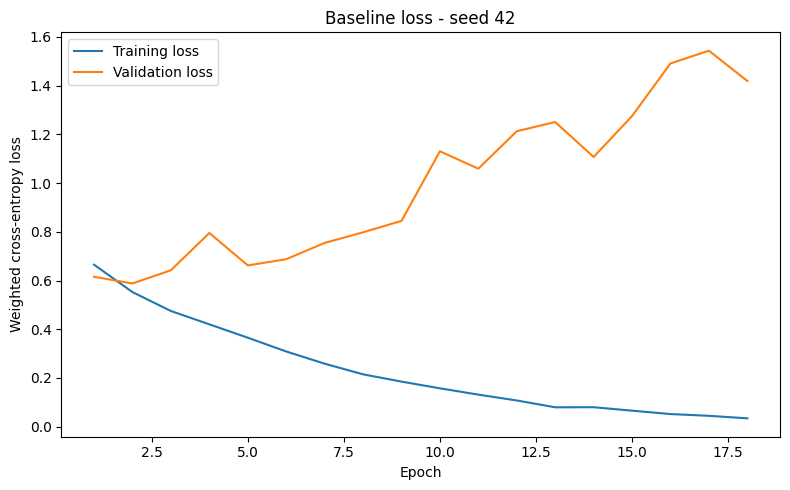

Saved: baseline_final_v2_seed_42_loss.png


In [23]:
## Plot training and validation loss


epochs = range(
    1,
    len(history["train_loss"]) + 1
)


plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history["train_loss"],
    label="Training loss",
)

plt.plot(
    epochs,
    history["validation_loss"],
    label="Validation loss",
)

plt.xlabel("Epoch")

plt.ylabel(
    "Weighted cross-entropy loss"
)

plt.title(
    f"Baseline loss - seed {TRAIN_SEED}"
)

plt.legend()
plt.tight_layout()


LOSS_FIGURE_PATH = (
    FIGURE_DIR
    / f"{RUN_NAME}_loss.png"
)

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=150,
)

plt.show()


print(
    f"Saved: "
    f"{LOSS_FIGURE_PATH.name}"
)

### 8.3 Validation balanced accuracy

Validation balanced accuracy is plotted across the epochs completed during training.

Balanced accuracy gives equal importance to the three diagnostic classes and is the metric used to select the best checkpoint.

The dashed vertical line shows the epoch with the highest validation balanced accuracy. This is the checkpoint retained for later evaluation.

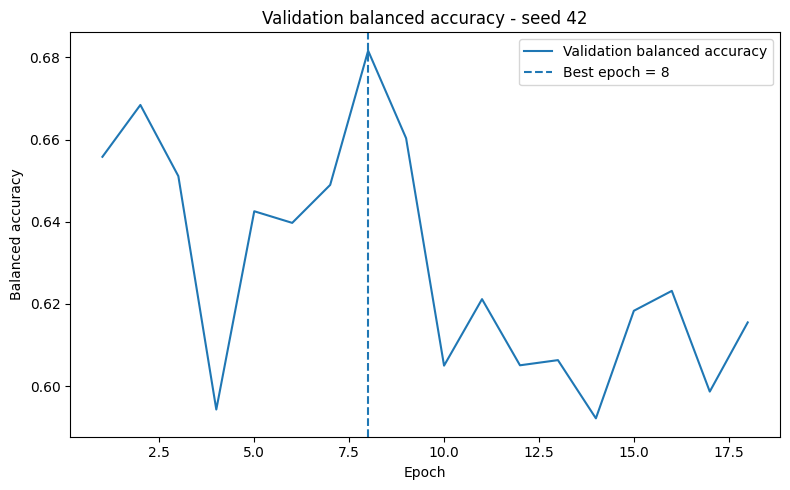

Saved: baseline_final_v2_seed_42_validation_ba.png


In [24]:
## Plot validation balanced accuracy

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    epochs,
    history[
        "validation_balanced_accuracy"
    ],
    label="Validation balanced accuracy",
)

plt.axvline(
    best_epoch,
    linestyle="--",
    label=f"Best epoch = {best_epoch}",
)

plt.xlabel("Epoch")

plt.ylabel(
    "Balanced accuracy"
)

plt.title(
    "Validation balanced accuracy "
    f"- seed {TRAIN_SEED}"
)

plt.legend()
plt.tight_layout()


VALIDATION_BA_FIGURE_PATH = (
    FIGURE_DIR
    / f"{RUN_NAME}_validation_ba.png"
)

plt.savefig(
    VALIDATION_BA_FIGURE_PATH,
    dpi=150,
)

plt.show()


print(
    f"Saved: "
    f"{VALIDATION_BA_FIGURE_PATH.name}"
)

## Section 9: Generate predictions from the selected checkpoint

The checkpoint with the highest validation balanced accuracy is reloaded after training.

The selected model is then used to generate predictions for the validation and test partitions. For each image, the predicted class and the probabilities for Benign, Indeterminate and Malignant are retained.

The original diagnosis metadata are also kept with the predictions. This allows later evaluation to distinguish the broad three-class target from more specific diagnostic analyses, including melanoma-focused evaluation.

This notebook does not perform the final ROC, sensitivity-specificity, calibration or cross-dataset analyses. These are calculated consistently in Notebook 05 after the baseline and multi-task runs have been completed.


### 9.1 Load the selected checkpoint

The best checkpoint saved during training is loaded into a fresh Swin-Tiny model.

The checkpoint metadata are checked before evaluation to make sure that the model architecture, training seed, class mapping and diagnostic target match the current baseline run.


In [25]:


## Load the selected checkpoint


checkpoint = torch.load(
    BEST_CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=True,
)


if checkpoint["model_name"] != MODEL_NAME:
    raise ValueError(
        "Checkpoint model does not match MODEL_NAME."
    )

if checkpoint["training_seed"] != TRAIN_SEED:
    raise ValueError(
        "Checkpoint seed does not match TRAIN_SEED."
    )

if checkpoint["run_name"] != RUN_NAME:
    raise ValueError(
        "Checkpoint run name does not match RUN_NAME."
    )

if checkpoint["class_to_idx"] != CLASS_TO_IDX:
    raise ValueError(
        "Checkpoint class mapping does not match CLASS_TO_IDX."
    )

if checkpoint["primary_target"] != PRIMARY_TARGET:
    raise ValueError(
        "Checkpoint target does not match PRIMARY_TARGET."
    )

if checkpoint["image_size"] != IMAGE_SIZE:
    raise ValueError(
        "Checkpoint image size does not match IMAGE_SIZE."
    )


best_epoch = int(
    checkpoint["epoch"]
)

best_validation_balanced_accuracy = float(
    checkpoint[
        "best_validation_balanced_accuracy"
    ]
)


eval_model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
)

eval_model.load_state_dict(
    checkpoint["model_state_dict"]
)

eval_model = eval_model.to(
    DEVICE
)

eval_model.eval()


print("=" * 67)
print(f"{'Selected checkpoint loaded':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"Checkpoint         : "
    f"{BEST_CHECKPOINT_PATH.name}"
)



                    Selected checkpoint loaded                     

Run name           : baseline_final_v2_seed_42
Training seed      : 42
Best epoch         : 8
Best validation BA : 0.6816
Checkpoint         : baseline_final_v2_seed_42_best.pt


### 9.2 Generate validation and test predictions

The selected checkpoint is applied to the validation and test partitions without updating the model.

Image IDs are collected directly from each DataLoader together with the true labels. The model outputs are converted to probabilities for the three diagnostic classes.

Probabilities are calculated in float32 before they are moved to the CPU and saved.

In [26]:

## Generate predictions


def run_inference(
    model,
    loader,
    device,
    use_amp,
):

    model.eval()

    all_ids = []
    all_labels = []
    all_predictions = []
    all_probabilities = []


    with torch.no_grad():

        for (
            images,
            labels,
            image_ids
        ) in loader:

            images = images.to(
                device,
                non_blocking=True,
            )


            with torch.amp.autocast(
                device_type=device.type,
                enabled=use_amp,
            ):

                outputs = model(
                    images
                )


            probabilities = torch.softmax(
                outputs.float(),
                dim=1,
            )

            predictions = probabilities.argmax(
                dim=1
            )


            all_ids.extend(
                [
                    str(image_id)
                    for image_id
                    in image_ids
                ]
            )

            all_labels.extend(
                labels.cpu().numpy().tolist()
            )

            all_predictions.extend(
                predictions.cpu().numpy().tolist()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy().tolist()
            )


    return {
        "ids":
            all_ids,

        "labels":
            np.asarray(
                all_labels,
                dtype=np.int64,
            ),

        "predictions":
            np.asarray(
                all_predictions,
                dtype=np.int64,
            ),

        "probabilities":
            np.asarray(
                all_probabilities,
                dtype=np.float32,
            ),
    }


validation_outputs = run_inference(
    model=eval_model,
    loader=validation_loader,
    device=DEVICE,
    use_amp=USE_AMP,
)

test_outputs = run_inference(
    model=eval_model,
    loader=test_loader,
    device=DEVICE,
    use_amp=USE_AMP,
)


print("=" * 67)
print(f"{'Inference complete':^67}")
print("=" * 67, "\n")

print(
    f"Validation images : "
    f"{len(validation_outputs['ids']):,}"
)

print(
    f"Test images       : "
    f"{len(test_outputs['ids']):,}"
)



                        Inference complete                         

Validation images : 3,808
Test images       : 3,851


### 9.3 Verify prediction alignment

Before the prediction files are saved, the collected image IDs and labels are checked against the fixed validation and test partitions.

The probability arrays are also checked for the expected three-class shape, finite values and rows that sum to one.

These checks help ensure that later evaluation uses predictions matched to the correct images and labels.

In [27]:
## Verify prediction alignment


def verify_predictions(
    dataframe,
    outputs,
    split_name,
):

    expected_ids = (
        dataframe["isic_id"]
        .astype(str)
        .tolist()
    )

    expected_labels = (
        dataframe[PRIMARY_TARGET]
        .map(CLASS_TO_IDX)
        .to_numpy()
    )


    if outputs["ids"] != expected_ids:
        raise ValueError(
            f"{split_name}: prediction IDs "
            "do not match the fixed split."
        )


    if not np.array_equal(
        outputs["labels"],
        expected_labels,
    ):
        raise ValueError(
            f"{split_name}: prediction labels "
            "do not match the fixed split."
        )


    expected_shape = (
        len(dataframe),
        NUM_CLASSES,
    )

    if (
        outputs["probabilities"].shape
        != expected_shape
    ):
        raise ValueError(
            f"{split_name}: probability shape "
            "is incorrect."
        )


    if not np.isfinite(
        outputs["probabilities"]
    ).all():

        raise ValueError(
            f"{split_name}: non-finite "
            "probabilities found."
        )


    if not np.allclose(
        outputs["probabilities"].sum(axis=1),
        1.0,
        atol=1e-5,
    ):

        raise ValueError(
            f"{split_name}: probabilities "
            "do not sum to one."
        )


    print(
        f"{split_name:10s}: "
        f"{len(expected_ids):,} predictions verified"
    )


print("=" * 67)
print(f"{'Prediction checks':^67}")
print("=" * 67, "\n")


verify_predictions(
    validation_df,
    validation_outputs,
    "Validation",
)

verify_predictions(
    test_df,
    test_outputs,
    "Test",
)



                         Prediction checks                         

Validation: 3,808 predictions verified
Test      : 3,851 predictions verified


### 9.4 Save validation and test predictions

The validation and test predictions are saved as separate CSV files.

Each row retains the image ID, the three diagnosis fields, the true and predicted three-class labels, and the predicted probability for each class.

`diagnosis_2` and `diagnosis_3` are retained as metadata rather than model targets. They provide the more detailed diagnostic information needed for later melanoma-focused evaluation.

For melanoma-versus-rest evaluation, `diagnosis_2` is used to identify melanoma ground truth, while `P(Malignant)` is used as the score. This is a broad malignancy score, and the model was not trained to separate melanoma from BCC or SCC.

The saved class probabilities allow Notebook 05 to calculate ROC curves and the required 90% and 95% sensitivity operating points for both malignant-versus-rest and melanoma-versus-rest analyses without rerunning the model.

In [28]:
## Save validation and test predictions


def build_prediction_table(
    dataframe,
    outputs,
    split_name,
):

    return pd.DataFrame({
        "isic_id":
            outputs["ids"],

        "diagnosis_1":
            dataframe["diagnosis_1"].values,

        "diagnosis_2":
            dataframe["diagnosis_2"].values,

        "diagnosis_3":
            dataframe["diagnosis_3"].values,

        "true_label":
            outputs["labels"],

        "true_class":
            [
                IDX_TO_CLASS[label]
                for label
                in outputs["labels"]
            ],

        "predicted_label":
            outputs["predictions"],

        "predicted_class":
            [
                IDX_TO_CLASS[label]
                for label
                in outputs["predictions"]
            ],

        "P_Benign":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Benign"]
            ],

        "P_Indeterminate":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Indeterminate"]
            ],

        "P_Malignant":
            outputs["probabilities"][
                :,
                CLASS_TO_IDX["Malignant"]
            ],

        "training_seed":
            TRAIN_SEED,

        "run_name":
            RUN_NAME,

        "split":
            split_name,
    })


validation_predictions_df = (
    build_prediction_table(
        validation_df,
        validation_outputs,
        "validation",
    )
)

test_predictions_df = (
    build_prediction_table(
        test_df,
        test_outputs,
        "test",
    )
)


VALIDATION_PREDICTIONS_PATH = (
    PREDICTION_DIR
    / f"{RUN_NAME}_validation_predictions.csv"
)

TEST_PREDICTIONS_PATH = (
    PREDICTION_DIR
    / f"{RUN_NAME}_test_predictions.csv"
)


validation_predictions_df.to_csv(
    VALIDATION_PREDICTIONS_PATH,
    index=False,
)

test_predictions_df.to_csv(
    TEST_PREDICTIONS_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Prediction files saved':^67}")
print("=" * 67, "\n")

print(
    f"Validation : "
    f"{VALIDATION_PREDICTIONS_PATH.name}"
)

print(
    f"Test       : "
    f"{TEST_PREDICTIONS_PATH.name}"
)




                      Prediction files saved                       

Validation : baseline_final_v2_seed_42_validation_predictions.csv
Test       : baseline_final_v2_seed_42_test_predictions.csv


### 9.5 Run-level check

Balanced accuracy is recalculated from the predictions produced by the selected checkpoint.

The validation value should reproduce the balanced accuracy stored with the checkpoint. Test balanced accuracy is shown as a descriptive result for this individual run and is not used to change the training protocol or select the model.

The final baseline result is calculated across all three seeds in Notebook 05.

In [29]:
## Run-level balanced accuracy

validation_balanced_accuracy_check = (
    balanced_accuracy_score(
        validation_outputs["labels"],
        validation_outputs["predictions"],
    )
)

test_balanced_accuracy_check = (
    balanced_accuracy_score(
        test_outputs["labels"],
        test_outputs["predictions"],
    )
)


if not np.isclose(
    validation_balanced_accuracy_check,
    best_validation_balanced_accuracy,
):
    raise ValueError(
        "Reloaded validation balanced accuracy "
        "does not match the saved checkpoint."
    )


print("=" * 67)
print(f"{'Run-level results':^67}")
print("=" * 67, "\n")

print(
    f"Validation BA : "
    f"{validation_balanced_accuracy_check:.4f}"
)

print(
    f"Test BA       : "
    f"{test_balanced_accuracy_check:.4f}"
)

                         Run-level results                         

Validation BA : 0.6816
Test BA       : 0.6938


## Section 10: Save the baseline run

The selected checkpoint, training history and prediction files form the record for this baseline seed.

A CSV version of the epoch-by-epoch training history is saved for easier inspection, and a compact JSON summary records the main run settings and output-file locations.

Final diagnostic, screening, calibration and cross-dataset metrics are calculated later in Notebook 05.

### 10.1 Save the training history

The epoch-by-epoch training history is saved as a CSV file.

This includes training loss, validation loss, validation balanced accuracy and the time taken for each completed epoch.

In [30]:

## Save the training history

HISTORY_CSV_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_training_history.csv"
)


history_df = pd.DataFrame({
    "epoch":
        np.arange(
            1,
            len(history["train_loss"]) + 1,
        ),

    "train_loss":
        history["train_loss"],

    "validation_loss":
        history["validation_loss"],

    "validation_balanced_accuracy":
        history[
            "validation_balanced_accuracy"
        ],

    "epoch_time_seconds":
        history[
            "epoch_time_seconds"
        ],
})


history_df.to_csv(
    HISTORY_CSV_PATH,
    index=False,
)


print("=" * 67)
print(f"{'Training history saved':^67}")
print("=" * 67, "\n")

print(
    f"Rows : {len(history_df)}"
)

print(
    f"File : {HISTORY_CSV_PATH.name}"
)



                      Training history saved                       

Rows : 18
File : baseline_final_v2_seed_42_training_history.csv


### 10.2 Save the run summary

A compact JSON file is saved with the main training settings, selected checkpoint information, run-level balanced accuracy values and the locations of the files produced by this run.

The summary does not contain the final ROC, sensitivity-specificity, melanoma, calibration or cross-dataset results because these are calculated in Notebook 05.

In [31]:
##
## Save the baseline run summary
##

SUMMARY_PATH = (
    RESULTS_DIR
    / f"{RUN_NAME}_summary.json"
)


run_summary = {
    "experiment":
        "diagnosis_only_baseline",

    "run_name":
        RUN_NAME,

    "model_name":
        MODEL_NAME,

    "training_seed":
        int(TRAIN_SEED),

    "image_size":
        int(IMAGE_SIZE),

    "batch_size":
        int(BATCH_SIZE),

    "learning_rate":
        float(LEARNING_RATE),

    "weight_decay":
        float(WEIGHT_DECAY),

    "maximum_epochs":
        int(MAX_EPOCHS),

    "early_stopping_patience":
        int(
            EARLY_STOPPING_PATIENCE
        ),

    "completed_epochs":
        int(completed_epochs),

    "stopped_early":
        bool(stopped_early),

    "checkpoint_selection":
        "validation balanced accuracy",

    "best_epoch":
        int(best_epoch),

    "best_validation_balanced_accuracy":
        float(
            best_validation_balanced_accuracy
        ),

    "reloaded_validation_balanced_accuracy":
        float(
            validation_balanced_accuracy_check
        ),

    "test_balanced_accuracy_run_level":
        float(
            test_balanced_accuracy_check
        ),

    "primary_target":
        PRIMARY_TARGET,

    "class_to_idx":
        {
            key: int(value)
            for key, value
            in CLASS_TO_IDX.items()
        },

    "class_counts":
        {
            class_name:
                int(
                    class_counts.loc[
                        class_name
                    ]
                )
            for class_name
            in CLASS_NAMES
        },

    "class_weights":
        {
            class_name:
                float(
                    class_weights.loc[
                        class_name
                    ]
                )
            for class_name
            in CLASS_NAMES
        },

    "class_weighting_method":
        CLASS_WEIGHTING_METHOD,

    "checkpoint_file":
        str(BEST_CHECKPOINT_PATH),

    "history_json_file":
        str(HISTORY_JSON_PATH),

    "history_csv_file":
        str(HISTORY_CSV_PATH),

    "validation_predictions_file":
        str(
            VALIDATION_PREDICTIONS_PATH
        ),

    "test_predictions_file":
        str(
            TEST_PREDICTIONS_PATH
        ),

    "loss_figure_file":
        str(LOSS_FIGURE_PATH),

    "validation_ba_figure_file":
        str(
            VALIDATION_BA_FIGURE_PATH
        ),
}


with open(
    SUMMARY_PATH,
    "w"
) as file:

    json.dump(
        run_summary,
        file,
        indent=2,
    )


print("=" * 67)
print(f"{'Run summary saved':^67}")
print("=" * 67, "\n")

print(
    f"File : {SUMMARY_PATH.name}"
)

                         Run summary saved                         

File : baseline_final_v2_seed_42_summary.json


### 10.3 Final integrity check

The main files produced by the baseline run are checked before the run is treated as complete.

The validation and test prediction tables are also checked to confirm that they contain the same number of rows as the corresponding fixed data partitions.

In [32]:
## Check the saved baseline outputs


files_to_check = {
    "best checkpoint":
        BEST_CHECKPOINT_PATH,

    "history JSON":
        HISTORY_JSON_PATH,

    "history CSV":
        HISTORY_CSV_PATH,

    "loss figure":
        LOSS_FIGURE_PATH,

    "validation BA figure":
        VALIDATION_BA_FIGURE_PATH,

    "validation predictions":
        VALIDATION_PREDICTIONS_PATH,

    "test predictions":
        TEST_PREDICTIONS_PATH,

    "run summary":
        SUMMARY_PATH,
}


print("=" * 67)
print(f"{'Baseline output check':^67}")
print("=" * 67, "\n")


for name, path in files_to_check.items():

    if not path.exists():
        raise FileNotFoundError(
            f"Missing {name}: {path}"
        )

    print(
        f"{name:24s}: OK"
    )


if (
    len(validation_predictions_df)
    != len(validation_df)
):
    raise ValueError(
        "Validation prediction row count "
        "does not match validation_df."
    )


if (
    len(test_predictions_df)
    != len(test_df)
):
    raise ValueError(
        "Test prediction row count "
        "does not match test_df."
    )


print(
    "\nAll required baseline files "
    "are present and prediction counts match."
)



                       Baseline output check                       

best checkpoint         : OK
history JSON            : OK
history CSV             : OK
loss figure             : OK
validation BA figure    : OK
validation predictions  : OK
test predictions        : OK
run summary             : OK

All required baseline files are present and prediction counts match.


### 10.4 Baseline run summary

The final cell prints the main information for this individual baseline run.

The final three-seed baseline result is calculated later in Notebook 05.

In [33]:
## Final baseline run summary


print("=" * 67)
print(f"{'Baseline run complete':^67}")
print("=" * 67, "\n")

print(f"Run name           : {RUN_NAME}")
print(f"Training seed      : {TRAIN_SEED}")
print(f"Completed epochs   : {completed_epochs}")
print(f"Stopped early      : {stopped_early}")
print(f"Best epoch         : {best_epoch}")

print(
    f"Best validation BA : "
    f"{best_validation_balanced_accuracy:.4f}"
)

print(
    f"Test BA            : "
    f"{test_balanced_accuracy_check:.4f}"
)

print(
    f"\nSummary file       : "
    f"{SUMMARY_PATH.name}"
)


                       Baseline run complete                       

Run name           : baseline_final_v2_seed_42
Training seed      : 42
Completed epochs   : 18
Stopped early      : True
Best epoch         : 8
Best validation BA : 0.6816
Test BA            : 0.6938

Summary file       : baseline_final_v2_seed_42_summary.json
